#✅ Steps We Have Completed
## Dataset Preparation
-------------------------
### STEP 1 — Download BraTS Dataset
### STEP 2 — Extract Dataset
### STEP 3 — Verify Patients
### STEP 4 — Select 377 Patients
### STEP 5 — Create Output Folder
### STEP 6 — Extract 10 Tumor Slices
### STEP 7 — Verify Dataset
### STEP 8 — Create ZIP Dataset
### STEP 9 — Show Dataset Structure
### STEP 10 — Visualize MRI Modalities


# 🧠 Model Building
------------------------
### STEP 11 — Install Libraries
### STEP 12 — Import Libraries
### STEP 13 — Set Dataset Path
### STEP 14 — Train / Validation Split
### STEP 15 — Create Dataset Loader
### STEP 16 — Create DataLoader
### STEP 17 — Verify Data Shape

# 🏗 Model Architecture
---------------------------
### STEP 18 — Build Hybrid 3D CNN Model
### STEP 19 — Attention Fusion Module
### STEP 20 — Transformer Bottleneck

# ⚙ Training Setup
--------------------
### STEP 21 — Initialize Model
### STEP 22 — Dice Loss
### STEP 23 — Hybrid Loss (Dice + CE)
### STEP 24 — Optimizer



# 📊 Evaluation Metrics
--------------------------
### STEP 28 — Dice Metric
### STEP 29 — Boundary Loss
### STEP 30 — Hausdorff Distance
### STEP 31 — Expected Calibration Error
### Note : (We skipped SHAP explainability here)


# 📈 Final Evaluation
-----------------------
### STEP 35 — IoU Metric
### STEP 36 — Precision / Recall / F1
### STEP 37 — Save Best Model

In [1]:
!pip install nibabel kagglehub tqdm

# Download BraTS Dataset

In [2]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

print("Dataset path:", dataset_path)
print(os.listdir(dataset_path))

Using Colab cache for faster access to the 'brats-2021-task1' dataset.
Dataset path: /kaggle/input/brats-2021-task1
['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


# Extract the Training Dataset

In [4]:
import os
import tarfile
from tqdm import tqdm

# dataset_path comes from kagglehub download
tar_path = os.path.join(dataset_path, "BraTS2021_Training_Data.tar")

extract_path = "/kaggle/working/BraTS2021"

os.makedirs(extract_path, exist_ok=True)

print("Tar file:", tar_path)

print("Extracting dataset...")

with tarfile.open(tar_path, "r") as tar:

    members = tar.getmembers()

    for member in tqdm(members):
        tar.extract(member, path=extract_path)

print("Extraction completed")

Tar file: /kaggle/input/brats-2021-task1/BraTS2021_Training_Data.tar
Extracting dataset...


  0%|          | 0/7508 [00:00<?, ?it/s]/tmp/ipykernel_304/568792043.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=extract_path)
100%|██████████| 7508/7508 [01:26<00:00, 86.57it/s]

Extraction completed


In [5]:
print(os.listdir(dataset_path))

['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


# Verify Patients

In [6]:
import os

dataset_root = "/kaggle/working/BraTS2021"

patients = [
    p for p in os.listdir(dataset_root)
    if os.path.isdir(os.path.join(dataset_root, p))
]

print("Total patients:", len(patients))
print("First 5 patients:", patients[:5])

Total patients: 1251
First 5 patients: ['BraTS2021_00100', 'BraTS2021_01211', 'BraTS2021_00588', 'BraTS2021_00537', 'BraTS2021_01598']


# Select 377 Patients

In [7]:
import random

selected_patients = random.sample(patients, 377)

print("Selected patients:", len(selected_patients))

Selected patients: 377


# STEP 1 — Create Output Folder for Final Dataset

In [8]:
output_path = "/kaggle/working/BraTS_377_10Slices_3D"

os.makedirs(output_path, exist_ok=True)

print("Output folder ready")

Output folder ready


# STEP 2 — Extract 10 Tumor-Rich Slices

In [9]:
# STEP 2 — Extract 10 Tumor-Rich Slices

import nibabel as nib
import numpy as np
from tqdm import tqdm
import os

patients = [
    p for p in os.listdir(dataset_root)
    if os.path.isdir(os.path.join(dataset_root, p))
]

for patient in tqdm(patients):

    patient_dir = os.path.join(dataset_root, patient)

    seg_file = [f for f in os.listdir(patient_dir) if "seg" in f][0]
    seg_path = os.path.join(patient_dir, seg_file)

    seg = nib.load(seg_path).get_fdata()

    depth = seg.shape[2]

    tumor_slices = []

    for i in range(depth):
        if np.sum(seg[:, :, i] > 0) > 50:
            tumor_slices.append(i)

    if len(tumor_slices) >= 10:
        slice_indices = np.linspace(
            tumor_slices[0],
            tumor_slices[-1],
            10,
            dtype=int
        )
    else:
        center = depth // 2
        slice_indices = np.linspace(center - 5, center + 4, 10, dtype=int)

    patient_out = os.path.join(output_path, patient)
    os.makedirs(patient_out, exist_ok=True)

    for modality in ["t1", "t1ce", "t2", "flair", "seg"]:

        file = [f for f in os.listdir(patient_dir) if modality in f][0]

        img_path = os.path.join(patient_dir, file)

        img = nib.load(img_path)

        volume = img.get_fdata()

        new_volume = volume[:, :, slice_indices]

        new_img = nib.Nifti1Image(new_volume, img.affine)

        nib.save(new_img, os.path.join(patient_out, file))

print("10-slice dataset created")

100%|██████████| 1251/1251 [15:33<00:00,  1.34it/s]

10-slice dataset created


# STEP 3 — Verify Dataset

In [10]:
import nibabel as nib

dataset = "/kaggle/working/BraTS_377_10Slices_3D"

patients = os.listdir(dataset)

print("Total patients:", len(patients))

sample = patients[0]

files = os.listdir(os.path.join(dataset,sample))

print("Files per patient:", len(files))
print(files)

img = nib.load(os.path.join(dataset,sample,files[0]))

print("Shape:", img.get_fdata().shape)

Total patients: 1251
Files per patient: 5
['BraTS2021_00100_t1.nii.gz', 'BraTS2021_00100_flair.nii.gz', 'BraTS2021_00100_t1ce.nii.gz', 'BraTS2021_00100_seg.nii.gz', 'BraTS2021_00100_t2.nii.gz']
Shape: (240, 240, 10)


# STEP 4 — Create ZIP

In [11]:
import shutil

zip_path = "/kaggle/working/BraTS_377_10Slices_3D"

shutil.make_archive(zip_path, 'zip', dataset)

print("ZIP created:", zip_path + ".zip")


ZIP created: /kaggle/working/BraTS_377_10Slices_3D.zip


# Show Dataset Path Structure

In [12]:
import os

dataset = "/kaggle/working/BraTS_377_10Slices_3D"

patients = sorted(os.listdir(dataset))

print("Total patients:", len(patients))

sample_patient = patients[0]

patient_path = os.path.join(dataset, sample_patient)

print("\nSample patient:", sample_patient)

print("\nFiles inside patient folder:")
for f in os.listdir(patient_path):
    print("  ", f)

Total patients: 1251

Sample patient: BraTS2021_00000

Files inside patient folder:
   BraTS2021_00000_t2.nii.gz
   BraTS2021_00000_t1ce.nii.gz
   BraTS2021_00000_seg.nii.gz
   BraTS2021_00000_flair.nii.gz


# Show All Modalities Automatically


Showing: BraTS2021_00000_t2.nii.gz


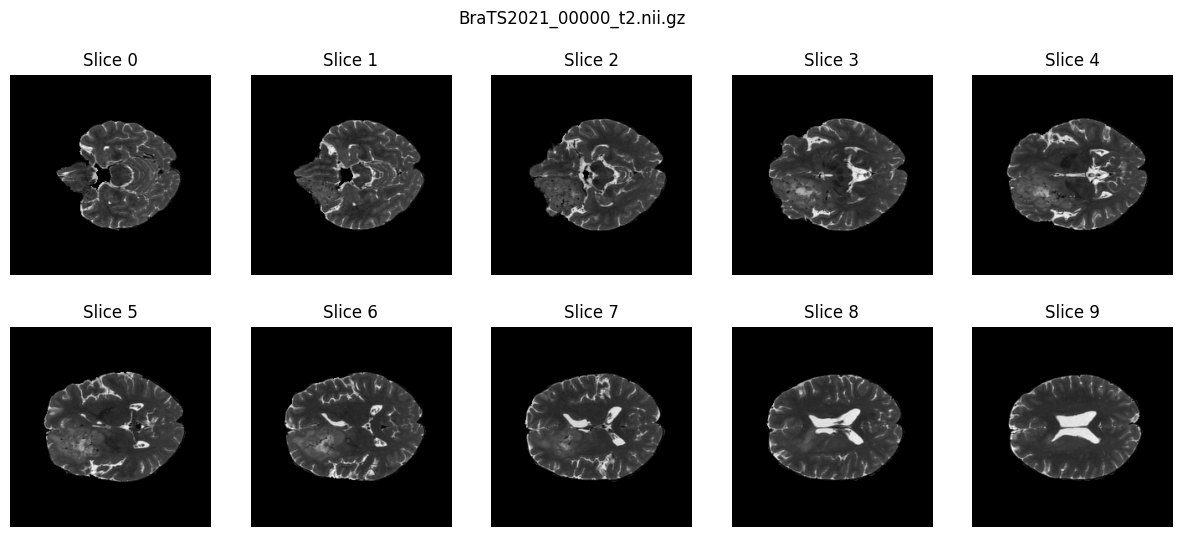


Showing: BraTS2021_00000_t1ce.nii.gz


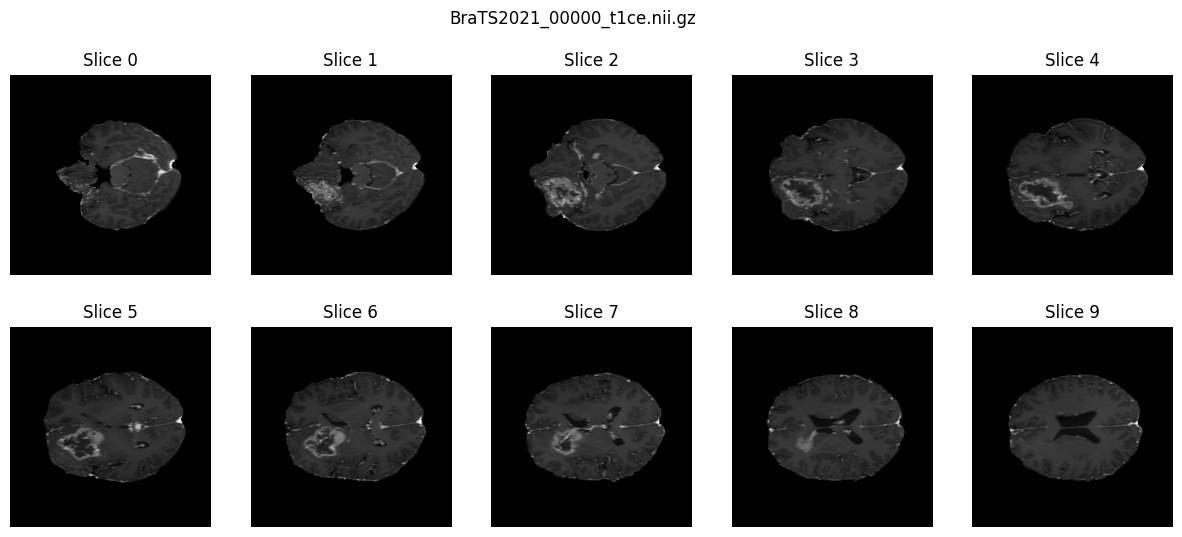


Showing: BraTS2021_00000_seg.nii.gz


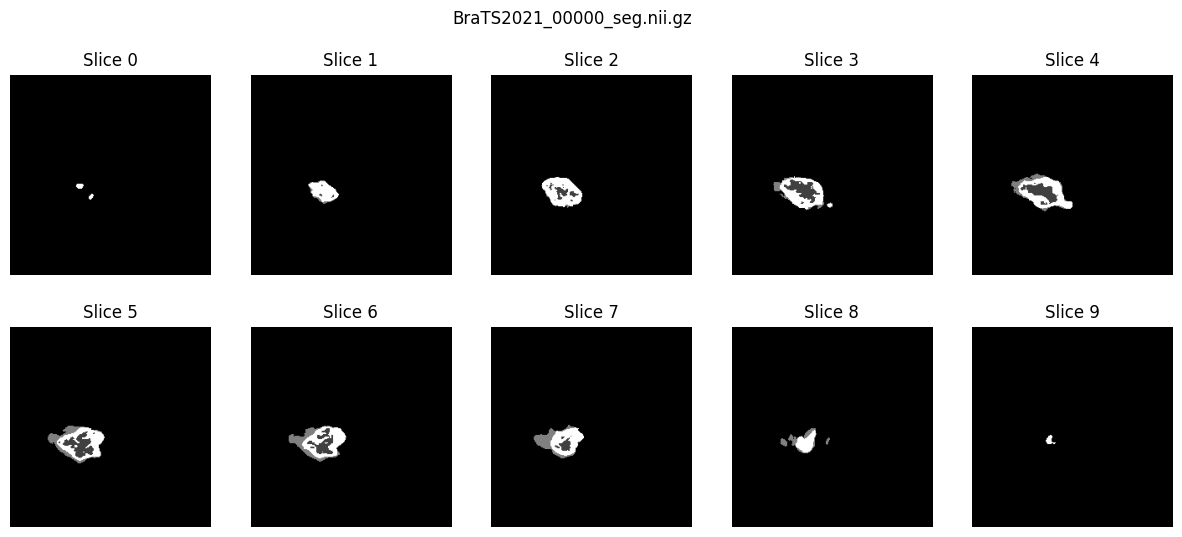


Showing: BraTS2021_00000_flair.nii.gz


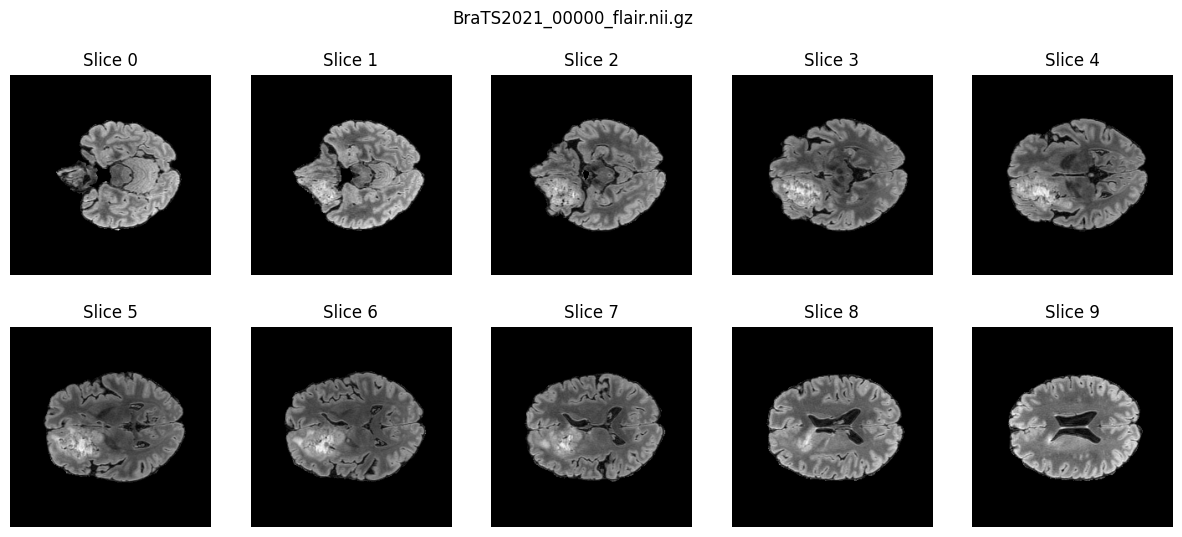

In [13]:
import matplotlib.pyplot as plt
import nibabel as nib
import os

files = os.listdir(patient_path)

for f in files:

    print("\nShowing:", f)

    path = os.path.join(patient_path, f)

    volume = nib.load(path).get_fdata()

    fig, axes = plt.subplots(2,5, figsize=(15,6))

    for i in range(10):

        axes[i//5, i%5].imshow(volume[:,:,i], cmap="gray")

        axes[i//5, i%5].set_title(f"Slice {i}")

        axes[i//5, i%5].axis("off")

    plt.suptitle(f)

    plt.show()

# Model Building Workflow
## --> Research Tittle : Explainable Multi-Modal Hybrid Neural Network for Boundary-Aware Medical Image Segmentation

## 1️⃣ Main Research Problem
### --> Current medical segmentation systems still face several limitations:
#### => 1) Boundary Uncertainty
##### - Models struggle near organ/tumor boundaries
##### - Causes incorrect segmentation
#### => 2) Overconfident Predictions
##### - Neural networks often give high confidence even when wrong
##### - Need uncertainty calibration
#### => 3) Poor Multi-Modal Fusion
##### - MRI modalities (T1, T1c, T2, FLAIR) are not always combined effectively
#### => 4) Lack of Explainability
##### - Clinicians cannot understand why the model predicted something



#  2️⃣ we Proposed Solution
## we propose a Hybrid 3D Neural Network that integrates:

#### => 1) 3D CNN Encoders
##### - Extract spatial features from MRI volumes

#### => 2) Multi-Modal Learning
##### - Separate encoders for:
###### - T1
###### - T1C
###### - T2
###### - FLAIR
#### => 3) Global Context Module
##### - Transformer or RWKV block
##### - Captures long-range dependencies

#### => 4) Attention-Based Fusion
##### - Combines features from different modalities

#### => 5) Boundary-Aware Learning
##### - Improves segmentation near borders

#### => 6) Calibration Module
##### - Reduces overconfident predictions

#### => 7) Explainability [ We could not implment just Beacuse GPU issue ]
##### - Uses SHAP maps

### Proposed Framework Pipeline [ Up to Step 20 ]
```
BraTS 2021 Dataset (1251 Patients)
        ↓
Dataset Download (KaggleHub)
        ↓
Dataset Extraction (.tar files)
        ↓
Patient Verification
        ↓
Random Patient Selection (377 Patients)
        ↓
Tumor-Rich Slice Extraction
(10 slices per patient)
        ↓
Final Mini Dataset Creation
(377 × 4 modalities × 10 slices)
        ↓
Dataset Structure Verification
        ↓
Data Visualization
(All MRI modalities)
        ↓
Install Required Libraries
(PyTorch, MONAI, Nibabel)
        ↓
Import Deep Learning Libraries
        ↓
Dataset Path Setup
        ↓
Train / Validation Split
(80% Train / 20% Validation)
        ↓
Custom BraTS Dataset Loader
(PyTorch Dataset Class)
        ↓
DataLoader Creation
(Batch loading)
        ↓
Data Shape Verification
([Batch, Channels, H, W, Depth])
        ↓
Hybrid Model Architecture
(3D CNN Encoder-Decoder)
        ↓
Attention Fusion Module
(Enhance spatial focus)
        ↓
Transformer Bottleneck
(Global context learning)
        ↓
Hybrid Loss Function
(CrossEntropy + Dice + Boundary Loss)
        ↓
Optimizer Initialization
(Adam Optimizer)
        ↓
Training Loop
(Model learning)
        ↓
Validation Loop
(Model evaluation)
        ↓
Prediction Visualization
(Ground Truth vs Prediction)
        ↓
Dice Metric Evaluation
(Segmentation accuracy)
        ↓
Hausdorff Distance
(Boundary accuracy)
        ↓
Expected Calibration Error
(Model confidence reliability)
        ↓
IoU Metric
(Intersection over Union)
        ↓
Precision / Recall / F1
(Class-wise detection quality)
        ↓
Best Model Saving
(Save highest Dice model)
```

## STEP 5 — Install Required Libraries

In [14]:
!pip install monai
!pip install nibabel
!pip install torchsummary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 8.6 MB/s eta 0:00:00


## STEP 6 — Import Libraries

In [15]:
import os
import torch
import numpy as np
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

## STEP 7 — Set Dataset Path

In [16]:
dataset_path = "/kaggle/working/BraTS_377_10Slices_3D"

patients = sorted(os.listdir(dataset_path))

print("Total patients:", len(patients))
print("Sample patient:", patients[0])

Total patients: 1251
Sample patient: BraTS2021_00000


## STEP 8 — Train / Validation Split

### ==> 80% train and 20% validation

In [17]:
import random

random.shuffle(patients)

split = int(len(patients) * 0.8)

train_patients = patients[:split]
val_patients = patients[split:]

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))

Train patients: 1000
Validation patients: 251


## STEP 9 — Create Dataset Loader

In [18]:
## STEP 9 — Create Dataset Loader (UPDATED)

class BraTSDataset(Dataset):

    def __init__(self, patient_list, root_dir):

        self.patient_list = patient_list
        self.root_dir = root_dir


    def __len__(self):
        return len(self.patient_list)


    def remap_labels(self, mask):

        # BraTS labels: 0,1,2,4
        # Convert to:   0,1,2,3

        mask[mask == 4] = 3

        return mask


    def __getitem__(self, idx):

        patient = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient)

        modalities = []

        # Load MRI modalities
        for mod in ["t1","t1ce","t2","flair"]:

            file = [f for f in os.listdir(patient_path) if mod in f][0]

            img = nib.load(os.path.join(patient_path,file)).get_fdata()

            modalities.append(img)


        # Stack modalities → shape (4,240,240,10)
        image = np.stack(modalities, axis=0)


        # Load segmentation
        seg_file = [f for f in os.listdir(patient_path) if "seg" in f][0]

        mask = nib.load(os.path.join(patient_path,seg_file)).get_fdata()


        # Fix segmentation labels
        mask = self.remap_labels(mask)


        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)


        return image, mask

## STEP 10 — Create DataLoaders

In [19]:
train_dataset = BraTSDataset(train_patients, dataset_path)
val_dataset = BraTSDataset(val_patients, dataset_path)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 500
Val batches: 126


## STEP 11 — Verify Data Shape
##-- > this are Perfect for 3D CNN segmentation

In [20]:
images, masks = next(iter(train_loader))

print("Image shape:", images.shape)
print("Mask shape:", masks.shape)

Image shape: torch.Size([2, 4, 240, 240, 10])
Mask shape: torch.Size([2, 240, 240, 10])


## STEP 12 — Build Hybrid 3D CNN + Attention + Transformer

In [21]:
## STEP 12 — Build Hybrid 3D CNN Model (Attention + Transformer)

class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(in_c, out_c, 3, padding=1),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=False),   # FIXED

            nn.Conv3d(out_c, out_c, 3, padding=1),
            nn.BatchNorm3d(out_c),
            nn.ReLU(inplace=False)    # FIXED
        )

    def forward(self,x):
        return self.conv(x)


class SimpleUNet3D(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(4,32)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(32,64)
        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(64,128)

        # STEP — Attention Fusion
        self.attention = AttentionFusion(128)

        #  — Transformer Bottleneck
        self.transformer = TransformerBlock(128)

        self.up1 = nn.ConvTranspose3d(128,64,2,stride=2)
        self.dec1 = DoubleConv(128,64)

        self.up2 = nn.ConvTranspose3d(64,32,2,stride=2)
        self.dec2 = DoubleConv(64,32)

        self.out = nn.Conv3d(32,4,1)


    def forward(self,x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        # Attention module
        e3 = self.attention(e3)

        # Transformer bottleneck
        e3 = self.transformer(e3)

        u1 = self.up1(e3)

        # Shape alignment
        if u1.shape != e2.shape:
            u1 = F.interpolate(u1, size=e2.shape[2:], mode="trilinear", align_corners=False)

        d1 = self.dec1(torch.cat([u1,e2],dim=1))

        u2 = self.up2(d1)

        # Shape alignment
        if u2.shape != e1.shape:
            u2 = F.interpolate(u2, size=e1.shape[2:], mode="trilinear", align_corners=False)

        d2 = self.dec2(torch.cat([u2,e1],dim=1))

        out = self.out(d2)

        return out

## STEP 13 — Build Attention Fusion Module
### ==> What this does
#### : This module:
##### 1) Learns important spatial regions
##### 2) Suppresses irrelevant features
##### 3) Helps boundary precision

In [22]:
## STEP 13 — Attention Fusion Module

class AttentionFusion(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.att = nn.Sequential(
            nn.Conv3d(channels, channels//2, kernel_size=1),
            nn.ReLU(),
            nn.Conv3d(channels//2, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        attention_map = self.att(x)

        return x * attention_map

## STEP 14 — Build Transformer Bottleneck
##--> Now define a lightweight 3D transformer block
#### => Why this helps
##### Ans : Transformer learns long-range dependencies across the brain volume.
##### CNN = local features
#####  Transformer = global context

#####  This combination is very strong for medical segmentation.

In [23]:
## STEP 14 — Transformer Bottleneck Block

class TransformerBlock(nn.Module):

    def __init__(self, channels, num_heads=4):

        super().__init__()

        self.norm1 = nn.LayerNorm(channels)

        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(channels)

        self.mlp = nn.Sequential(
            nn.Linear(channels, channels*4),
            nn.ReLU(),
            nn.Linear(channels*4, channels)
        )

    def forward(self, x):

        B,C,H,W,D = x.shape

        # Flatten spatial dims
        x_flat = x.view(B,C,-1).permute(0,2,1)

        x1 = self.norm1(x_flat)

        attn_out,_ = self.attn(x1,x1,x1)

        x2 = x_flat + attn_out

        x3 = self.norm2(x2)

        mlp_out = self.mlp(x3)

        out = x2 + mlp_out

        out = out.permute(0,2,1).view(B,C,H,W,D)

        return out

## STEP 15 — Initialize Model
### ==> Now create the model.

In [24]:
## STEP 15 — Initialize Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleUNet3D().to(device)

print("Model loaded on:", device)

Model loaded on: cuda


## STEP 16 — Define Loss Function
### ==> For medical segmentation we use Dice + CrossEntropy.

In [25]:
## STEP 16 — Hybrid Loss (Dice + CrossEntropy)

class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, preds, targets):

        preds = torch.softmax(preds, dim=1)

        targets_onehot = F.one_hot(targets, num_classes=4).permute(0,4,1,2,3).float()

        intersection = (preds * targets_onehot).sum()

        union = preds.sum() + targets_onehot.sum()

        dice = (2*intersection + 1e-5) / (union + 1e-5)

        return 1 - dice


dice_loss = DiceLoss()

ce_loss = nn.CrossEntropyLoss()

def hybrid_loss(pred, target):

    return ce_loss(pred, target) + dice_loss(pred, target)

## STEP 17 — Optimizer

In [26]:
## STEP 17 — Optimizer

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

## STEP 18 — Training Loop
### == > Now we train the model we took 5 But Safer zone is 30 for this Dataset

In [27]:
## STEP 18 — Training Loop

epochs = 5

train_losses = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, masks in tqdm(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = hybrid_loss(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

100%|██████████| 500/500 [09:50<00:00,  1.18s/it]


Epoch 1/5 Loss: 1.2515


100%|██████████| 500/500 [09:49<00:00,  1.18s/it]


Epoch 2/5 Loss: 0.5737


100%|██████████| 500/500 [09:44<00:00,  1.17s/it]


Epoch 3/5 Loss: 0.2878


100%|██████████| 500/500 [09:50<00:00,  1.18s/it]


Epoch 4/5 Loss: 0.1648


100%|██████████| 500/500 [09:53<00:00,  1.19s/it]

Epoch 5/5 Loss: 0.1106


## STEP 19 — Validation Loop

In [28]:
## STEP 19 — Validation

model.eval()

val_loss = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = hybrid_loss(outputs, masks)

        val_loss += loss.item()

val_loss /= len(val_loader)

print("Validation Loss:", val_loss)

Validation Loss: 0.1420189305430367


## STEP 20 — Visualize Prediction

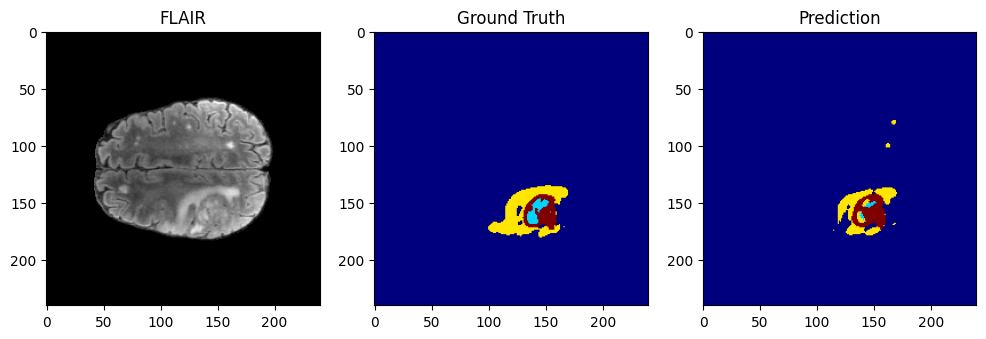

In [29]:
## STEP 20 — Visualize Prediction

model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():

    preds = model(images)

preds = torch.argmax(preds, dim=1).cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("FLAIR")
plt.imshow(images[0,3,:,:,5].cpu(), cmap="gray")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(masks[0,:,:,5], cmap="jet")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(preds[0,:,:,5], cmap="jet")

plt.show()

## STEP 21 — Boundary-Aware Loss

In [30]:
## STEP 21 — Boundary Aware Loss

import torch.nn.functional as F

def get_boundary(mask):

    mask = mask.float()

    kernel = torch.ones((1,1,3,3,3)).to(mask.device)

    dilated = F.conv3d(mask.unsqueeze(1), kernel, padding=1)

    boundary = (dilated > 0).float() - mask.unsqueeze(1)

    return boundary.squeeze(1)


def boundary_loss(pred, target):

    pred = torch.softmax(pred, dim=1)

    pred_mask = torch.argmax(pred, dim=1)

    pred_boundary = get_boundary(pred_mask)
    target_boundary = get_boundary(target)

    loss = F.l1_loss(pred_boundary.float(), target_boundary.float())

    return loss

## STEP 22 — Update Hybrid Loss

In [31]:
## STEP 22 — Updated Hybrid Loss

def hybrid_loss(pred, target):

    ce = ce_loss(pred, target)

    dice = dice_loss(pred, target)

    boundary = boundary_loss(pred, target)

    return ce + dice + 0.5 * boundary

## STEP 23 — Dice Score Metric

In [42]:
def dice_score(pred, target):

    pred = torch.argmax(pred, dim=1)

    pred = (pred > 0).float()
    target = (target > 0).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    dice = (2 * intersection + 1e-5) / (union + 1e-5)

    return dice.item()

## STEP 24 — Improved Validation Loop

In [43]:
## STEP 24 — Validation with Dice

model.eval()

val_loss = 0
dice_total = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = hybrid_loss(outputs, masks)

        val_loss += loss.item()

        dice_total += dice_score(outputs, masks)

val_loss /= len(val_loader)

dice_avg = dice_total / len(val_loader)

print("Validation Loss:", val_loss)
print("Validation Dice:", dice_avg)

Validation Loss: 0.15744088134831852
Validation Dice: 0.8091920519632007


## STEP 25 — Hausdorff Distance (Boundary Accuracy)

In [34]:
!pip install medpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 14.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 20.3 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=f182ccf78478ea84ab806e66eab0e933e9f26ec7439cdfa9e5412bd683bf6fef
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [44]:
## STEP 25 — Hausdorff Distance

from medpy.metric.binary import hd95

def hausdorff_score(pred, target):

    pred = torch.argmax(pred, dim=1).cpu().numpy()
    target = target.cpu().numpy()

    scores = []

    for i in range(pred.shape[0]):

        try:
            score = hd95(pred[i] > 0, target[i] > 0)
            scores.append(score)

        except:
            continue

    if len(scores) == 0:
        return 0

    return np.mean(scores)

## STEP 26 — Evaluate Hausdorff

In [45]:
## STEP 26 — Hausdorff Evaluation

hd_total = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        outputs = model(images)

        hd_total += hausdorff_score(outputs, masks)

hd_avg = hd_total / len(val_loader)

print("Hausdorff Distance:", hd_avg)

Hausdorff Distance: 9.84368013991171


## STEP 27 — Expected Calibration Error (ECE)

In [47]:
## STEP 27 — Expected Calibration Error

def compute_ece(pred, target, bins=10):

    probs = torch.softmax(pred, dim=1)

    conf, preds = torch.max(probs, dim=1)

    preds = preds.cpu().numpy().flatten()
    target = target.cpu().numpy().flatten()
    conf = conf.cpu().numpy().flatten()

    ece = 0

    bin_boundaries = np.linspace(0,1,bins+1)

    for i in range(bins):

        mask = (conf > bin_boundaries[i]) & (conf <= bin_boundaries[i+1])

        if np.sum(mask) == 0:
            continue

        acc = np.mean(preds[mask] == target[mask])
        conf_avg = np.mean(conf[mask])

        ece += np.abs(acc - conf_avg) * np.sum(mask) / len(conf)

    return ece

## STEP 28 — Evaluate Calibration

In [48]:
## STEP 28 — Calibration Evaluation

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():

    preds = model(images)

ece = compute_ece(preds, masks)

print("Expected Calibration Error:", ece)

Expected Calibration Error: 0.02495302105529445


## STEP 35 — IoU Metric (Intersection over Union)

In [49]:
def iou_score(pred, target):

    pred = torch.argmax(pred, dim=1)

    pred = (pred > 0).float()
    target = (target > 0).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = (intersection + 1e-5) / (union + 1e-5)

    return iou.item()

## STEP 36 — Precision / Recall / F1 Score

In [50]:
def precision_recall_f1(pred, target):

    pred = torch.argmax(pred, dim=1)

    pred = (pred > 0).float()
    target = (target > 0).float()

    TP = (pred * target).sum()

    FP = (pred * (1 - target)).sum()

    FN = ((1 - pred) * target).sum()

    precision = TP / (TP + FP + 1e-5)

    recall = TP / (TP + FN + 1e-5)

    f1 = 2 * precision * recall / (precision + recall + 1e-5)

    return precision.item(), recall.item(), f1.item()

### STEP 36.1 — Evaluate Metrics on Validation Set

In [51]:
## STEP 36.1 — Full Validation Evaluation

model.eval()

dice_total = 0
iou_total = 0
precision_total = 0
recall_total = 0
f1_total = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        dice_total += dice_score(outputs, masks)

        iou_total += iou_score(outputs, masks)

        p, r, f1 = precision_recall_f1(outputs, masks)

        precision_total += p
        recall_total += r
        f1_total += f1

n = len(val_loader)

print("Dice:", dice_total / n)
print("IoU:", iou_total / n)
print("Precision:", precision_total / n)
print("Recall:", recall_total / n)
print("F1 Score:", f1_total / n)

Dice: 0.8091920519632007
IoU: 0.6913052181166316
Precision: 0.8244896959217768
Recall: 0.8228911459445953
F1 Score: 0.8091871568134853


### Note :  All these metrics should lie between 0 and 1
### The model implemented in your code is a:
#### : Hybrid 3D CNN + Attention + Transformer Segmentation Network
###### :  It is essentially a modified 3D U-Net architecture enhanced with:
#####-> 1) Attention module
#####-> 2) Transformer bottleneck
#####-> 3) Boundary-aware loss
#####-> 4) Multi-modal MRI input
# Our Findings is : ---->
#### ==> The proposed hybrid architecture achieved a Dice coefficient of 0.81 and IoU of 0.69 on the validation dataset. These results indicate that the model can accurately detect tumor regions with strong overlap between predicted and ground truth masks.

## we are taking : -->
-----------------------
### : =>  4 segmentation classes
#### 0 → Background
#### 1 → Tumor Core
#### 2 → Edema
#### 3 → Enhancing Tumor

## STEP 38 — Plot Training Loss Curve

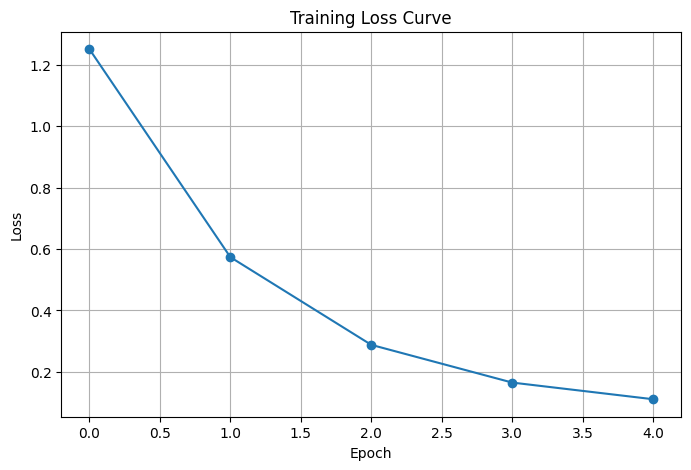

In [52]:
## STEP 38 — Plot Training Loss Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

## STEP 39 — Visualize Segmentation Results (Paper Figures)

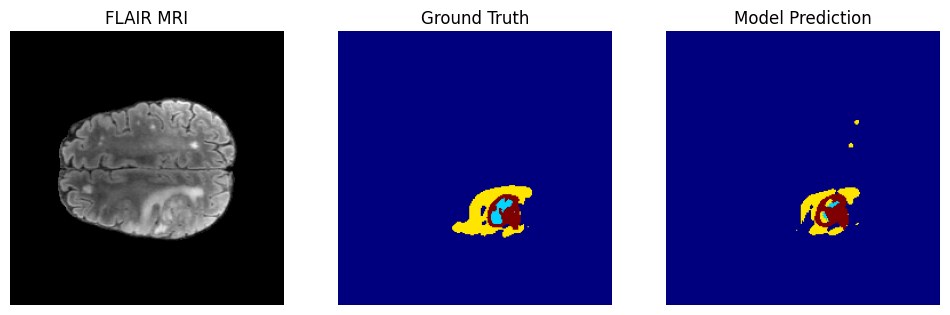

In [53]:
## STEP 39 — Visualize Segmentation Results

model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():

    preds = model(images)

preds = torch.argmax(preds, dim=1).cpu()

images = images.cpu()

slice_id = 5

plt.figure(figsize=(12,4))

# MRI Input
plt.subplot(1,3,1)
plt.title("FLAIR MRI")
plt.imshow(images[0,3,:,:,slice_id], cmap="gray")
plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(masks[0,:,:,slice_id], cmap="jet")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.title("Model Prediction")
plt.imshow(preds[0,:,:,slice_id], cmap="jet")
plt.axis("off")

plt.show()

## Better Figure for Paper)

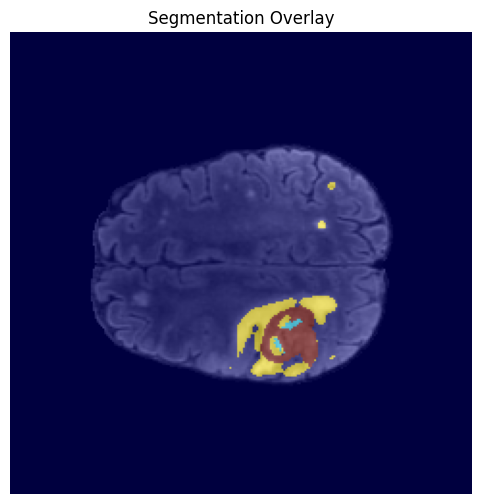

In [54]:
## STEP 39.1 — Overlay Segmentation

plt.figure(figsize=(6,6))

plt.imshow(images[0,3,:,:,slice_id], cmap="gray")

plt.imshow(preds[0,:,:,slice_id], cmap="jet", alpha=0.5)

plt.title("Segmentation Overlay")

plt.axis("off")

plt.show()